---
### Group Alpha
- Amira Aqila Afdhal
- Christian
- Ditya Ayu Anjani
---

# Project Overview: Telco Customer Churn

**Stakeholders**
>Lorem ipsum dolor sit amet, consectetur adipiscing elit. In iaculis tortor nec egestas tempor. Nam pretium dictum hendrerit. Aliquam at molestie lorem, at commodo nisl. Sed faucibus ex magna, quis ullamcorper nisi posuere quis. Integer condimentum nibh ac elementum dapibus. Duis vitae venenatis ante. Pellentesque at justo fermentum, varius enim eget, porttitor eros. Vivamus luctus leo vel augue euismod sollicitudin. Quisque congue purus in ligula laoreet, a efficitur sem pellentesque. Suspendisse vel maximus urna.

**Problem Statement**
>Lorem ipsum dolor sit amet, consectetur adipiscing elit. In iaculis tortor nec egestas tempor. Nam pretium dictum hendrerit. Aliquam at molestie lorem, at commodo nisl. Sed faucibus ex magna, quis ullamcorper nisi posuere quis. Integer condimentum nibh ac elementum dapibus. Duis vitae venenatis ante. Pellentesque at justo fermentum, varius enim eget, porttitor eros. Vivamus luctus leo vel augue euismod sollicitudin. Quisque congue purus in ligula laoreet, a efficitur sem pellentesque. Suspendisse vel maximus urna.

**Goal**
>Lorem ipsum dolor sit amet, consectetur adipiscing elit. In iaculis tortor nec egestas tempor. Nam pretium dictum hendrerit. Aliquam at molestie lorem, at commodo nisl. Sed faucibus ex magna, quis ullamcorper nisi posuere quis. Integer condimentum nibh ac elementum dapibus. Duis vitae venenatis ante. Pellentesque at justo fermentum, varius enim eget, porttitor eros. Vivamus luctus leo vel augue euismod sollicitudin. Quisque congue purus in ligula laoreet, a efficitur sem pellentesque. Suspendisse vel maximus urna.

# Import Libraries

In [1]:
# Save Model
import pickle
import os

# Data & Array
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Model Selection & Training
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

# Optional: to suppress warnings
import warnings

warnings.filterwarnings("ignore")

# Optional: Pandas display option
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)

# Data
1. Read Dataset
1. Data Profiling
1. Data Cleansing
1. Data Transformation

## 1. Read Dataset

---
**Feature Descriptions**
1. `customerID`
1. `gender` Whether the customer is a male or a female
1. `SeniorCitizen` Whether the customer is a senior citizen or not (1, 0)
1. `Partner` Whether the customer has a partner or not (Yes, No)
1. `Dependents` Whether the customer has dependents or not (Yes, No)
1. `tenure` Number of months the customer has stayed with the company
1. `PhoneService` Whether the customer has a phone service or not (Yes, No)
1. `MultipleLines` Whether the customer has multiple lines or not (Yes, No, No phone service)
1. `InternetService` Customer’s internet service provider (DSL, Fiber optic, No)
1. `OnlineSecurity` Whether the customer has online security or not (Yes, No, No internet service)
1. `OnlineBackup` Whether the customer has online backup or not (Yes, No, No internet service)
1. `DeviceProtection` Whether the customer has device protection or not (Yes, No, No internet service)
1. `TechSupport` Whether the customer has tech support or not (Yes, No, No internet service)
1. `StreamingTV` Whether the customer has streaming TV or not (Yes, No, No internet service)
1. `StreamingMovies` Whether the customer has streaming movies or not (Yes, No, No internet service)
1. `Contract` The contract term of the customer (Month-to-month, One year, Two year)
1. `PaperlessBilling` Whether the customer has paperless billing or not (Yes, No)
1. `PaymentMethod` The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
1. `MonthlyCharges` The amount charged to the customer monthly
1. `TotalCharges` The total amount charged to the customer
1. `Churn` Whether the customer churned or not (Yes or No)
---

In [2]:
# Telco Customer Churn Dataset
df = pd.read_csv("input/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2607,5539-TMZLF,Male,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.75,69.75,Yes
995,3842-IYKUE,Female,0,No,No,35,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),85.30,2917.5,Yes
1096,4646-QZXTF,Female,0,Yes,No,7,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),81.25,580.1,No
4505,6917-FIJHC,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,26.00,1776,No
6354,3214-IYUUQ,Female,0,Yes,No,61,Yes,No,Fiber optic,Yes,Yes,No,Yes,No,Yes,One year,No,Bank transfer (automatic),93.70,5860.7,No


## 2. Data profiling

In [3]:
# Column data type
dtype = pd.DataFrame(df.dtypes).rename(columns={0: "Data Type"})

# Column value
value = pd.DataFrame(df.head(1)).T.rename(columns={0: "Value"})

dtype.join(value)

,Data Type,Value
customerID,object,7590-VHVEG
gender,object,Female
SeniorCitizen,int64,0
Partner,object,Yes
Dependents,object,No
tenure,int64,1
PhoneService,object,No
MultipleLines,object,No phone service
InternetService,object,DSL
OnlineSecurity,object,No


In [4]:
# Check invalid value
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Check unique value
pd.DataFrame(df.nunique()).rename(columns={0: "Unique Value"})

,Unique Value
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [6]:
# Drop the columns with many unique values
check_unique = df.drop(
    columns=["customerID", "MonthlyCharges", "TotalCharges"]
)

# Unique values for each remaining column
unique_values = pd.DataFrame({
    "Column": check_unique.columns,
    "Unique Values": [", ".join(map(str, check_unique[col].dropna().unique())) 
                     for col in check_unique.columns]
})

# Display the result
unique_values

,Column,Unique Values
0,gender,"Female, Male"
1,SeniorCitizen,"0, 1"
2,Partner,"Yes, No"
3,Dependents,"No, Yes"
4,tenure,"1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71, 21, 12, 30, 47, 72, 17, 27, 5, 46, 11, 70, 63, 43, 15, 60, 18, 66, 9, 3, 31, 50, 64, 56, 7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37, 36, 41, 6, 4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19, 54, 51, 26, 0, 39"
5,PhoneService,"No, Yes"
6,MultipleLines,"No phone service, No, Yes"
7,InternetService,"DSL, Fiber optic, No"
8,OnlineSecurity,"No, Yes, No internet service"
9,OnlineBackup,"Yes, No, No internet service"


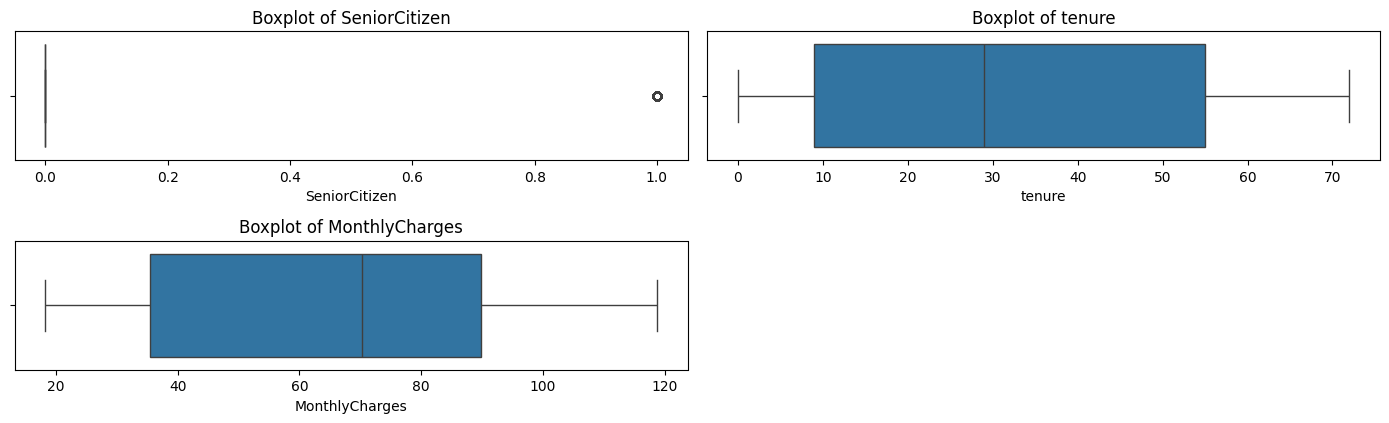

In [7]:
numeric_columns = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Visualization
plt.figure(figsize=(14, 6))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
plt.show()

In [8]:
# Check correlation
check_corr = df[numeric_columns]

check_corr.corr(method="pearson")

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


**Result:**
1. `Partner` Change No to 0 and Yes to 1 also change the data type to float
1. `Dependents` Change No to 0 and Yes to 1 also change the data type to float
1. `PhoneService` Change No to 0 and Yes to 1 also change the data type to float
1. `PaperlessBilling` Change No to 0 and Yes to 1 also change the data type to float
1. `Churn` Change No to 0 and Yes to 1 also change the data type to float
1. `tenure` change data type to float
1. `TotalCharges` change data type to float

## 3. Data Cleansing
1. Handle Missing Values
1. Handle Duplicates

### Handle Missing Values

In [9]:
# Check how many row effected by missing values
check_missing = pd.DataFrame(
    round(df.isna().sum() / len(df) * 100, 2).astype(str) + "%"
).rename(columns={0: "Missing Value"})

check_missing

,Missing Value
customerID,0.0%
gender,0.0%
SeniorCitizen,0.0%
Partner,0.0%
Dependents,0.0%
tenure,0.0%
PhoneService,0.0%
MultipleLines,0.0%
InternetService,0.0%
OnlineSecurity,0.0%


<div class="alert alert-success">There are no missing values</div>

### Handle Invalid Values

In [10]:
df[df["TotalCharges"]==" "] = 0.0

<div class="alert alert-danger">Change " " to 0</div>

### Remove Duplicates

In [11]:
# Check how many row have duplicate
pd.DataFrame(df.duplicated().value_counts())

,count
False,7033
True,10


In [12]:
df = df.drop_duplicates()

<div class="alert alert-danger">Drop 10 rows</div>

## 4. Data Transformation
1. Mapping
1. Convert data types

**Result:**
1. `Partner` Change No to 0 and Yes to 1 also change the data type to float
1. `Dependents` Change No to 0 and Yes to 1 also change the data type to float
1. `PhoneService` Change No to 0 and Yes to 1 also change the data type to float
1. `PaperlessBilling` Change No to 0 and Yes to 1 also change the data type to float
1. `Churn` Change No to 0 and Yes to 1 also change the data type to float
1. `tenure` change data type to float
1. `TotalCharges` change data type to float

### Mapping

In [13]:
cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]
# Change 0 to No and 1 to Yes
for col in cols:
    df[col] = df[col].map({"0": "No", "1": "Yes"})
    print(df, col)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     NaN         No       1   
1     5575-GNVDE    Male              0     NaN         No      34   
2     3668-QPYBK    Male              0     NaN         No       2   
3     7795-CFOCW    Male              0     NaN         No      45   
4     9237-HQITU  Female              0     NaN         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     NaN        Yes      24   
7039  2234-XADUH  Female              0     NaN        Yes      72   
7040  4801-JZAZL  Female              0     NaN        Yes      11   
7041  8361-LTMKD    Male              1     NaN         No       4   
7042  3186-AJIEK    Male              0     NaN         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL             No   
1             Yes  

### Convert Data types

In [14]:
# Change data type from int to float
df[["tenure", "TotalCharges"]] = df[["tenure", "TotalCharges"]].astype(float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7033 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7033 non-null   object 
 1   gender            7033 non-null   object 
 2   SeniorCitizen     7033 non-null   int64  
 3   Partner           0 non-null      object 
 4   Dependents        0 non-null      object 
 5   tenure            7033 non-null   float64
 6   PhoneService      0 non-null      object 
 7   MultipleLines     7033 non-null   object 
 8   InternetService   7033 non-null   object 
 9   OnlineSecurity    7033 non-null   object 
 10  OnlineBackup      7033 non-null   object 
 11  DeviceProtection  7033 non-null   object 
 12  TechSupport       7033 non-null   object 
 13  StreamingTV       7033 non-null   object 
 14  StreamingMovies   7033 non-null   object 
 15  Contract          7033 non-null   object 
 16  PaperlessBilling  0 non-null      object 
 17  

In [16]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,NaN,NaN,1.0,NaN,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,NaN,Electronic check,29.85,29.85,NaN
1,5575-GNVDE,Male,0,NaN,NaN,34.0,NaN,No,DSL,Yes,No,Yes,No,No,No,One year,NaN,Mailed check,56.95,1889.50,NaN
2,3668-QPYBK,Male,0,NaN,NaN,2.0,NaN,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,NaN,Mailed check,53.85,108.15,NaN
3,7795-CFOCW,Male,0,NaN,NaN,45.0,NaN,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,NaN,Bank transfer (automatic),42.30,1840.75,NaN
4,9237-HQITU,Female,0,NaN,NaN,2.0,NaN,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,NaN,NaN,24.0,NaN,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,NaN,Mailed check,84.80,1990.50,NaN
7039,2234-XADUH,Female,0,NaN,NaN,72.0,NaN,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,NaN,Credit card (automatic),103.20,7362.90,NaN
7040,4801-JZAZL,Female,0,NaN,NaN,11.0,NaN,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,NaN,Electronic check,29.60,346.45,NaN
7041,8361-LTMKD,Male,1,NaN,NaN,4.0,NaN,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Mailed check,74.40,306.60,NaN
